# IS 470 Assignment 3: Predicting Wine Quality

<b>Objective:</b> In this assignment, you will predict the quality of wines (target variable) based on various
chemical attributes. The goal is to perform regression analysis using OLS, regression trees, SVR, and MLP
models on a dataset, and then compare these models.

In [22]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# Import libraries
import pandas as pd               # used for data analysis and manipulation
import seaborn as sns             # used for data visualization (used for lots of charts, box plot, scatter plot etc...)
import matplotlib.pyplot as plt   # used for data visualization (specifically for plotting the decision tree classifier)

# note, previously we were importing specific module functions from sklearn.  This is not necessary since internally they do not have any naming conflicts
import sklearn as sk              # used for a bunch of things, DecisionTreeClassifier and more.
import numpy as np



In [24]:
red_wine_quality = pd.read_csv('/content/drive/MyDrive/IS470_data/winequality-red.csv')
red_wine_quality.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Business Understanding
Core understanding: This dataset is regarding the characteristics and quality of red wine.  Each record represents the median of at least 3 evaluations made by wine experts who graded the wine quality from 0 to 10 (note: 11 possible values).<br/><br/>
Note: The values represent only physiochemical inputs (aka, inputs that were determined by analysing the wine chemically as opposed to knowing anything about the manufacturing process such as type of grapes used or any details about the manufacturer)<br/><br/>
Main objective: To determine which factors influence perceived wine quality<br/>
Stakeholders: The people who benefit from this analysis are as follows
  * Winemakers: Primarily because this affects their business
  * Distributors: Are also affected by the quality of wine
  * Quality Inspectors: Will be able to get answers about quality without as much investigation because they can look at the numbers<br/><br/>

Decisions: The results of this study will help manufacturers target specific markets for their wine and carve out a niche for their particular tastes.  It may also help them define a brand or set of characteristics which could be beneficial in marketing.
Pricing Strategy: will also be affected by this data.  Note, it is not necessarily the goal to make the highest quality wine but rather to make the most money, this involves both the quality of the wine and the cost to make and distribute it.<br/><br/>
The core goal is a numeric regression (prediction) of wine quality.


## Data Understanding
**fixed acidity:**  These are acids which are non-volatile (aka they don't evaporate even if the wine is warmed), They include tartaric, malic, citric and lactic acid.  They contribute to the wines fresh/crisp taste and affect the overall pH and color of the wine</br><br/>
**volatile acidity:**  These are acids that can evaporate, they primarily affect the smell<br/><br/>
**citric acid:**  This acid is from fruits primarily including grapes, it is used to enhance freshness and color stability.<br/><br/>
**residual sugar:**  When wine ferments (aka becomes alcoholic) most of the sugar is converted into alcohol, This sugar is what remains.  It affects the sweetness of the wine.<br/><br/>
**chlorides:**  These are basically salts. They affect something called "mouthfeel" and body and also can have an effect on the perceived sweetness<br/><br/>
**free sulfur dioxide:**  This chemical is involved with the preservation of the wine, it is an antioxidant and an antimicrobal agent.  Free sulfur dioxide is active and actually protects the wine.<br/><br/>
**total sulfur dioxide:**  Not all sulfer dioxide is free, meaning that some of it has bound with other chemicals and that part is not active.  This part has no real effect on the wine, unfortunately for regulatory and labeling purposes only total sulfur dioxide is reported (making it difficult to determine the preservation qualities)<br/><br/>
**density:**  This value indicates how heavy the wine is compared to water, the higher the number essentially the more sugar and less alcohol<br/><br/>
**pH:**  This is a measure of the concentration of hydrogen ions (aka the acidity).  numbers from 0-7 are considered acidic, 7 is neutral and 7-14 is "basic" (or alkaline/non-acidic)<br/><br/>
**sulphates:**  Not to be confused with sulphites which are preservatives, These chemicals effect the freshness/minerality and mouthfeel of the wine<br/><br/>
**alchohol:** This is the result of the fermentation process of the grapes.  It determines flavor, body, stability and mouthfeel<br/><br/>
**quality:** This is the target variable, it's the result of a minimum of 3 observations by wine experts and it graded from 0 to 10<br/><br/>


### Data Understanding / Context
Above, is a simple listing of all the variables we have, however there is not a lot of context here. For context, we need to look more closely at them.<br/>

The first goal I see is to determine if there are any highly correlated values. if so, we might want to remove some of them to make the data more balanced.



In [25]:
corr = red_wine_quality.corr()
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


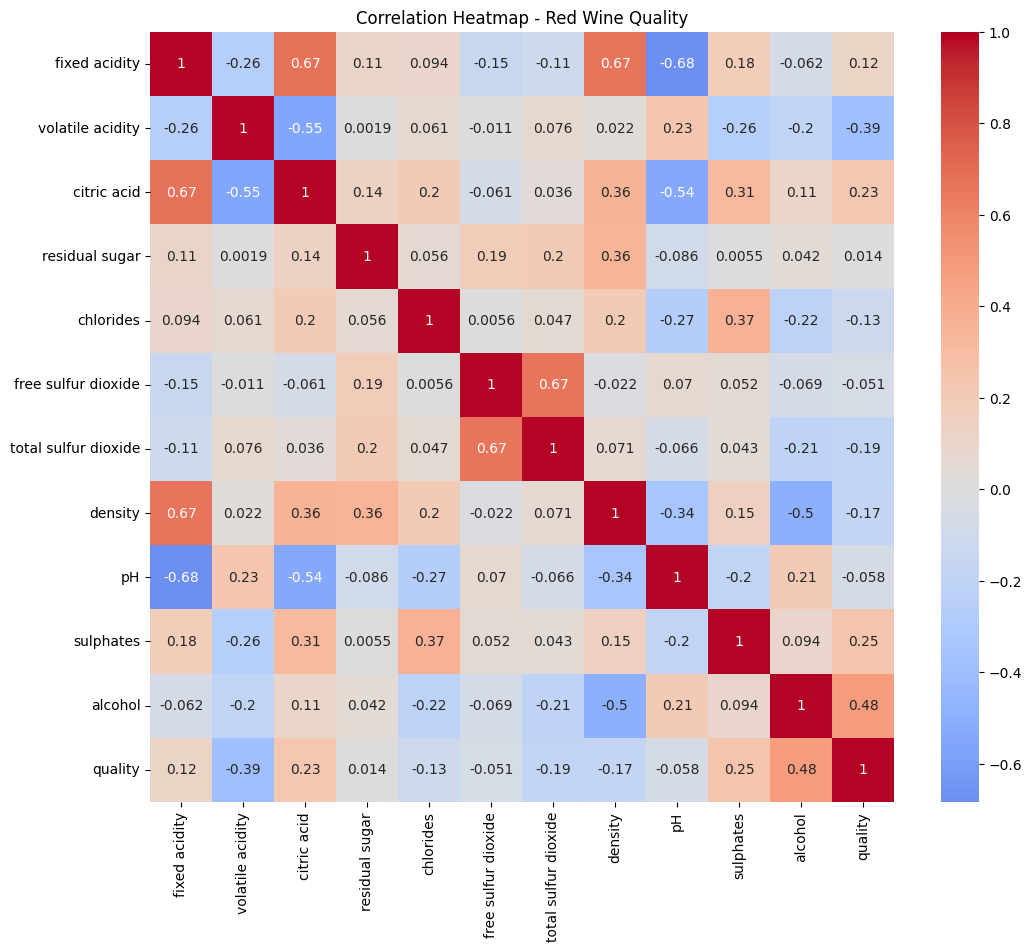

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Red Wine Quality')
plt.show()

Looking at the above data, I can see a high correlation between both pH and density an fixed acidity, which you would expect, however I don't se any very high correlations with the target value of quality.  The highest correlation would be alcohol content, but even that is only .48  I don't know that it makes sense to remove any of these variables from analysis.

## Data Preparation

In [27]:
print(red_wine_quality.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


There doesn't appear to be any null values, that's good



In [28]:
# ok lets see datatypes now
print(red_wine_quality.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


Again, just checking here for anything wierd. In this case however it appears all normal. These are infact all numbers not categorical.

### Product Quality
I don't have to do a lot of analysis to determine the main factors in product quality.  It is clear that the most obvius factor is in fact the alcohol content, which is unfortunate because it's just so obvious.  It's also unfortunate because I suspect increasing the alcohol content is one of the more expensive things to do.<br/><br/>
The second most important factor however, is interesting and that is the sulphate level.  It's interesting to me, because I have no idea what a sulphate is or how it tastes or how you go about getting more or less of it in your wine, but if I were a wine manufacturer, this is definitely where I would be focusing my research.

### Success Criteria
What is success in our context?  Is it being able to predict the quality?  This seems trivial to me.  I can predict it fairly accurate by looking at one value (alcohol content) so what good is this to me as a business?  Any other business can do the same thing, which lowers my product down to a simple commodity.   As a business, I want to diversify my product.  In order to do that, I need to generate actionable insights, and quite frankly I need more than just the data provided here, however this is a start.<br/><br/>
For example, as I said before we can research sulphates and also citric acid (the third most important factor).  In a real word situation, I would likely have many more sets of data to work with.<br/><br/>
For example, If I was aware of what the most common categories of wine are in stores I could use that information to construct a wine in a specific way.  I see this going two ways.   One would be to create a wine that is difinitively categorizable into a known location and thereby becomes the benchmark for that type of wine, however the opposite strategy might also be good.  Making a wine that could fall into many categories might actually get it noticed more often than a standard one.  Only experimentation would determine what method is best.


### Lets graph some stuff to see if we can gain a better understanding of the data

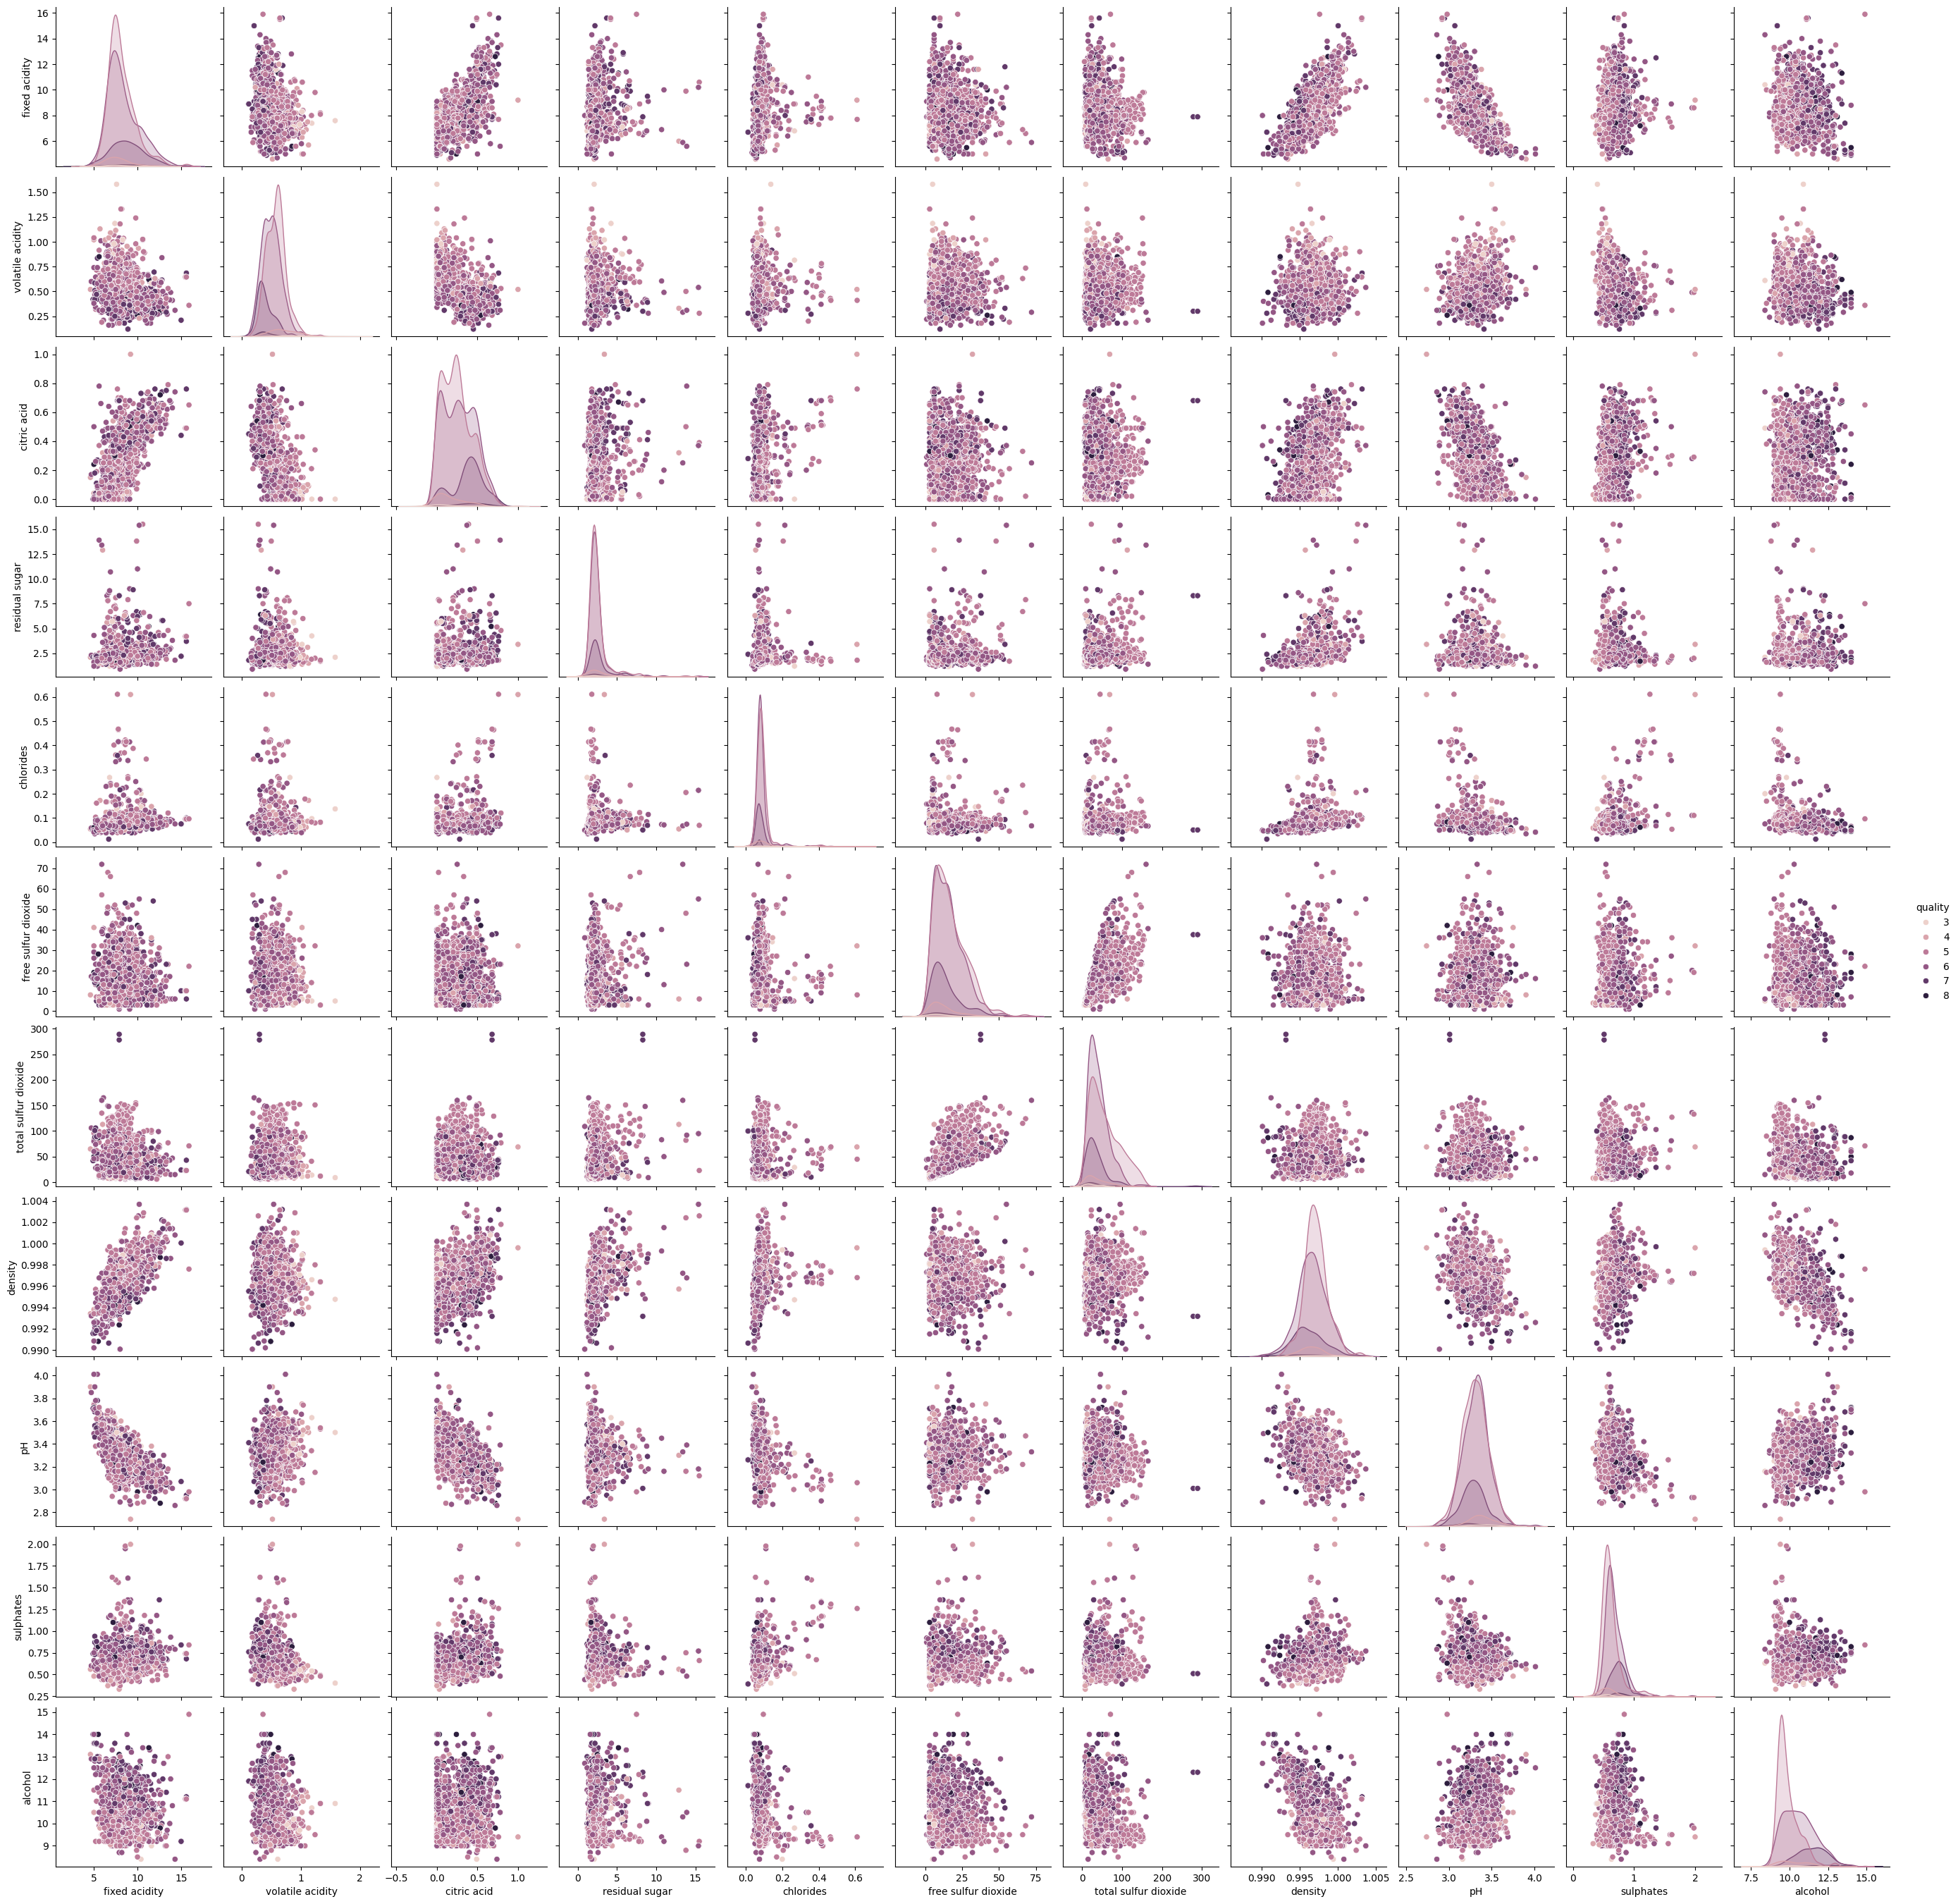

In [29]:
# Lets do some pair plots
sns.pairplot(data=red_wine_quality, hue='quality')
plt.show()


## Preparing the data<br/>


In [30]:
predictors = red_wine_quality.drop('quality', axis=1)
p_train, p_test, t_train, t_test = sk.model_selection.train_test_split(predictors, red_wine_quality['quality'], test_size=0.2, random_state=42)
print(p_train.shape, p_test.shape, t_train.shape, t_test.shape)

(1279, 11) (320, 11) (1279,) (320,)


## Create models and do analysis

In [31]:
# simple linear regression with one predictor (alchohol)
slr = sk.linear_model.LinearRegression()
slr.fit(p_train[['alcohol']], t_train)


LinearRegression()

In [32]:
# multiple linear regression (all predictors)
mlr = sk.linear_model.LinearRegression()
mlr.fit(p_train, t_train)

LinearRegression()

In [33]:
# regression tree
rt = sk.tree.DecisionTreeRegressor(random_state=42)
rt.fit(p_train, t_train)


DecisionTreeRegressor(random_state=42)

In [34]:
# support vector regression
svr = sk.pipeline.make_pipeline(sk.preprocessing.StandardScaler(), sk.svm.SVR())
svr.fit(p_train, t_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svr', SVR())])

In [35]:
# multilayer perceptron (neural network)
mlp = sk.neural_network.MLPRegressor(hidden_layer_sizes=(100,100), max_iter=2000, random_state=42)
mlp.fit(p_train, t_train)

MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=2000, random_state=42)

In [36]:
# evaluate the models using MAE and RMSE
models = {
    "Simple LR": slr,
    "Multiple LR": mlr,
    "Regression Tree": rt,
    "SVR": svr,
    "MLP": mlp
}

for name, model in models.items():
  if name == "Simple LR":
    preds = model.predict(p_test[['alcohol']])
  else:
    preds = model.predict(p_test)
  mae = sk.metrics.mean_absolute_error(t_test, preds)
  rmse = np.sqrt(sk.metrics.mean_squared_error(t_test, preds))
  print(f"{name} - MAE: {mae:.3f}, RMSE: {rmse:.3f}")

Simple LR - MAE: 0.575, RMSE: 0.707
Multiple LR - MAE: 0.504, RMSE: 0.625
Regression Tree - MAE: 0.463, RMSE: 0.779
SVR - MAE: 0.454, RMSE: 0.593
MLP - MAE: 0.478, RMSE: 0.605


In [37]:
# Classification
clf = sk.tree.DecisionTreeClassifier(criterion="entropy", random_state=42, max_depth=3)
clf.fit(p_train, t_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

[Text(0.5, 0.875, 'alcohol <= 10.525\nentropy = 1.706\nsamples = 1279\nvalue = [9.0, 43.0, 551.0, 506.0, 157.0, 13.0]'),
 Text(0.25, 0.625, 'sulphates <= 0.575\nentropy = 1.398\nsamples = 786\nvalue = [6.0, 27.0, 465.0, 256.0, 30.0, 2.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'total sulfur dioxide <= 98.5\nentropy = 1.217\nsamples = 314\nvalue = [4.0, 20.0, 225.0, 61.0, 4.0, 0.0]'),
 Text(0.0625, 0.125, 'entropy = 1.338\nsamples = 263\nvalue = [4, 20, 176, 59, 4, 0]'),
 Text(0.1875, 0.125, 'entropy = 0.239\nsamples = 51\nvalue = [0, 0, 49, 2, 0, 0]'),
 Text(0.375, 0.375, 'total sulfur dioxide <= 81.5\nentropy = 1.41\nsamples = 472\nvalue = [2, 7, 240, 195, 26, 2]'),
 Text(0.3125, 0.125, 'entropy = 1.447\nsamples = 388\nvalue = [2.0, 5.0, 173.0, 181.0, 25.0, 2.0]'),
 Text(0.4375, 0.125, 'entropy = 0.896\nsamples = 84\nvalue = [0, 2, 67, 14, 1, 0]'),
 Text(0.75, 0.625, 'sulphates <= 0.585\nentropy = 1.768\nsamples = 493\nvalue = [3.0, 16.0, 86.0, 250.0, 127.0, 11.0]'),
 Tex

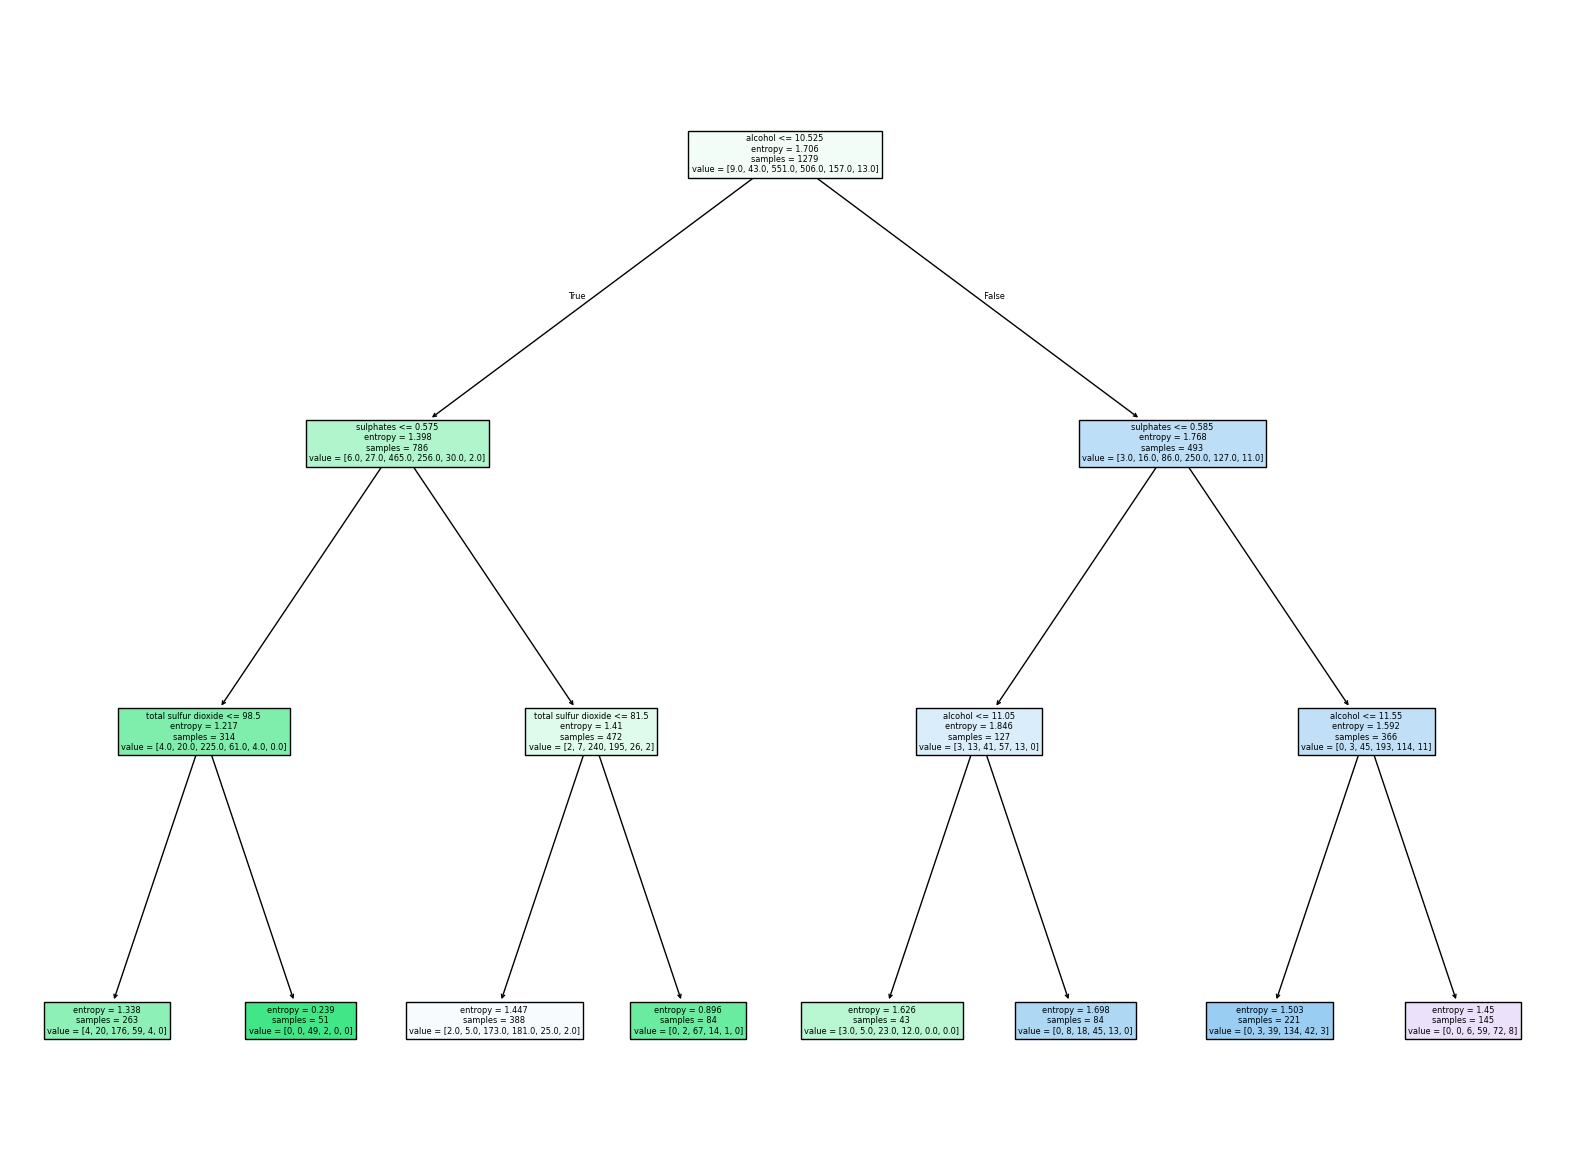

In [38]:
# plot the tree
fig = plt.figure(figsize=(20,15))
sk.tree.plot_tree(clf, feature_names=list(p_train.columns), filled=True)

## Evaluation<br/>
Reviewing the results from the first set of models (regression models) it appears that SVR is the most effective, because the values are lowest for MAE and RMSE.<br/><br/>
SVR is followed by Regression Tree and MLP to make the top three regression models.

The DecisionTreeClassifier is in a different category so cannot be compared to the other three

Summary:

The regression models predict the quality score from 1 to 10 and therefore performance is measured using error-based metrics (MAE, RMSE)

The classification model predicts categories so accuracy based metrics are appropriate.  Because these are different prediction tasks with different evaluation criteria, the regression and clasification models cannot be directly compared numerically.

Which one to use then?

It depends on your goals.  If the goal is simply to determine how to make the best wine then perhaps the regression models would suit you best, however my opinion is that this cannot be the goal from a business perspective.  Only one wine can be "the best".  What is more effective would be to figure out where your wines fit categorically among other wines.  This would require more data of course, but would likely also use a Classifier rather than a Regression model.

Another way to approach this problem would be to use both.  Use Classifiers to determine which general category (from a business perspective) your wine will fall into, then use Regression to ensure that you have the best wine among that category.




## Deployment<br/>
The CRISP-DM model states that there needs to be a deployment phase.  In the real world, this would likely involve creating the code and submitting it via version control into an automated deployment pipeline.  For this class however the following code will suffice to deploy our models to google drive where they can be copied and submitted.

In [39]:
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/IS470_Assignment03.ipynb" --to html --output "/content/drive/MyDrive/Output/IS470_Assignment03.html"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470_Assignment03.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 526085 bytes to /content/drive/MyDrive/Output/IS470_Assignment03.html
